# Week 5: Evaluation and Explainability
## Earthquake Alert Classification

In [8]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import subprocess
import importlib
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Install SHAP only if it is missing
if importlib.util.find_spec('shap') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])

import shap

## 1. Load Data and Prepare Features

In [9]:
df = pd.read_csv('earthquake_processed.csv')

FEATURES = ['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'depth_mag_ratio']
TARGET = 'alert_encoded'
LABEL_MAP = {0: 'green', 1: 'yellow', 2: 'orange', 3: 'red'}

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('\nClass distribution in y_test:')
print(y_test.value_counts().sort_index())

Train shape: (1004, 6)
Test shape : (252, 6)

Class distribution in y_test:
alert_encoded
0    65
1    63
2    60
3    64
Name: count, dtype: int64


## 2. Load Saved Models for Evaluation

In [10]:
model_dir = 'saved_models'
model_files = {
    'Random Forest (saved)': os.path.join(model_dir, 'rf_best.pkl'),
    'Gradient Boosting (saved)': os.path.join(model_dir, 'gb_custom.pkl'),
    'XGBoost (saved)': os.path.join(model_dir, 'xgb_best.pkl')
}

missing = [name for name, path in model_files.items() if not os.path.exists(path)]
if missing:
    raise FileNotFoundError(
        f"Missing saved model files for: {missing}. "
        f"Expected under '{model_dir}'."
    )

models = {name: joblib.load(path) for name, path in model_files.items()}

# Keep explicit handles for downstream sections
rf_model = models['Random Forest (saved)']
gb_model = models['Gradient Boosting (saved)']
xgb_model = models['XGBoost (saved)']

predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test)

print('Saved models loaded and predictions generated successfully.')
for name, path in model_files.items():
    print(f'- {name}: {path}')

Saved models loaded and predictions generated successfully.
- Random Forest (saved): saved_models\rf_best.pkl
- Gradient Boosting (saved): saved_models\gb_custom.pkl
- XGBoost (saved): saved_models\xgb_best.pkl


## 3. Confusion Matrix and Classification Report

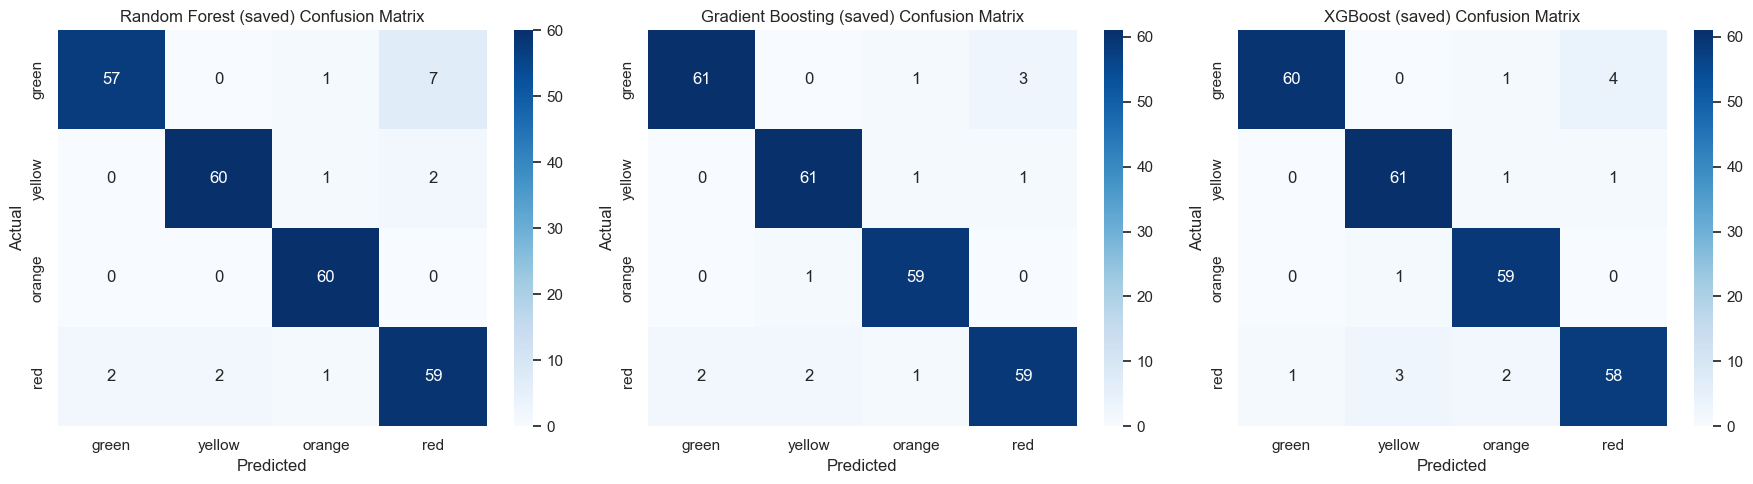


Random Forest (saved) Classification Report
              precision    recall  f1-score   support

       green       0.97      0.88      0.92        65
      yellow       0.97      0.95      0.96        63
      orange       0.95      1.00      0.98        60
         red       0.87      0.92      0.89        64

    accuracy                           0.94       252
   macro avg       0.94      0.94      0.94       252
weighted avg       0.94      0.94      0.94       252


Gradient Boosting (saved) Classification Report
              precision    recall  f1-score   support

       green       0.97      0.94      0.95        65
      yellow       0.95      0.97      0.96        63
      orange       0.95      0.98      0.97        60
         red       0.94      0.92      0.93        64

    accuracy                           0.95       252
   macro avg       0.95      0.95      0.95       252
weighted avg       0.95      0.95      0.95       252


XGBoost (saved) Classification Repo

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[LABEL_MAP[i] for i in sorted(LABEL_MAP)],
        yticklabels=[LABEL_MAP[i] for i in sorted(LABEL_MAP)],
        ax=ax
    )
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

for name, y_pred in predictions.items():
    print(f'\n{name} Classification Report')
    print(classification_report(y_test, y_pred, target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]))

## 4. MAE and MSE Comparison Plots

,Accuracy,MAE,MSE,Precision,Recall,F1
Model,,,,,,
Random Forest (saved),0.9365,0.1548,0.4087,0.9382,0.9365,0.9365
Gradient Boosting (saved),0.9524,0.1032,0.2540,0.9524,0.9524,0.9523
XGBoost (saved),0.9444,0.1151,0.2738,0.9451,0.9444,0.9443


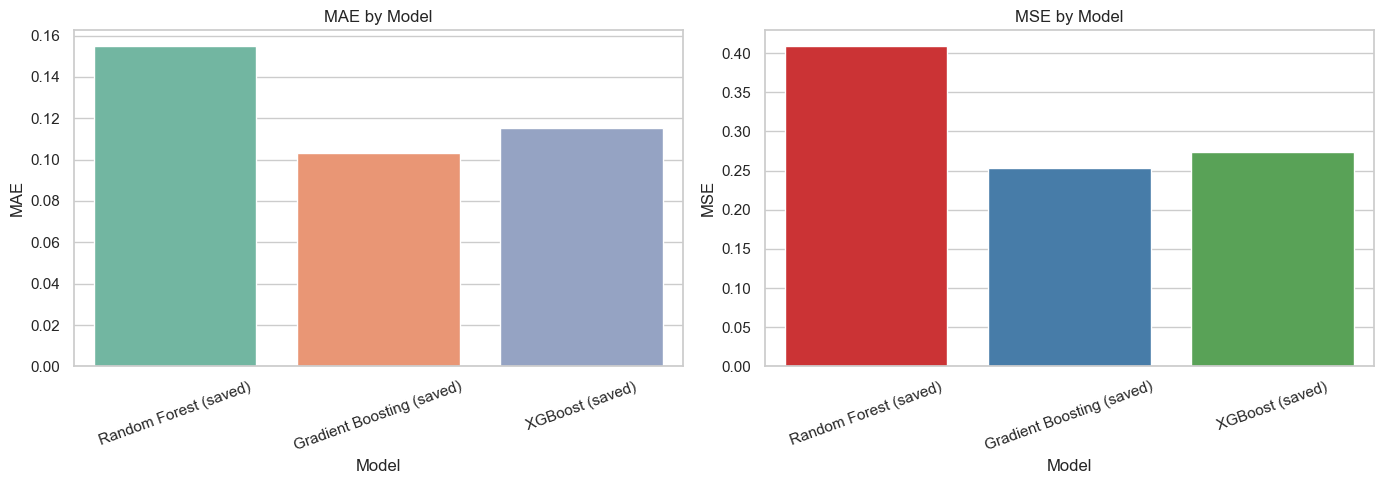

In [12]:
metric_rows = []
for name, y_pred in predictions.items():
    metric_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1': f1_score(y_test, y_pred, average='weighted')
    })

metrics_df = pd.DataFrame(metric_rows).set_index('Model')
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=metrics_df.index, y=metrics_df['MAE'].values, ax=axes[0], palette='Set2')
axes[0].set_title('MAE by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=metrics_df.index, y=metrics_df['MSE'].values, ax=axes[1], palette='Set1')
axes[1].set_title('MSE by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Feature Importance

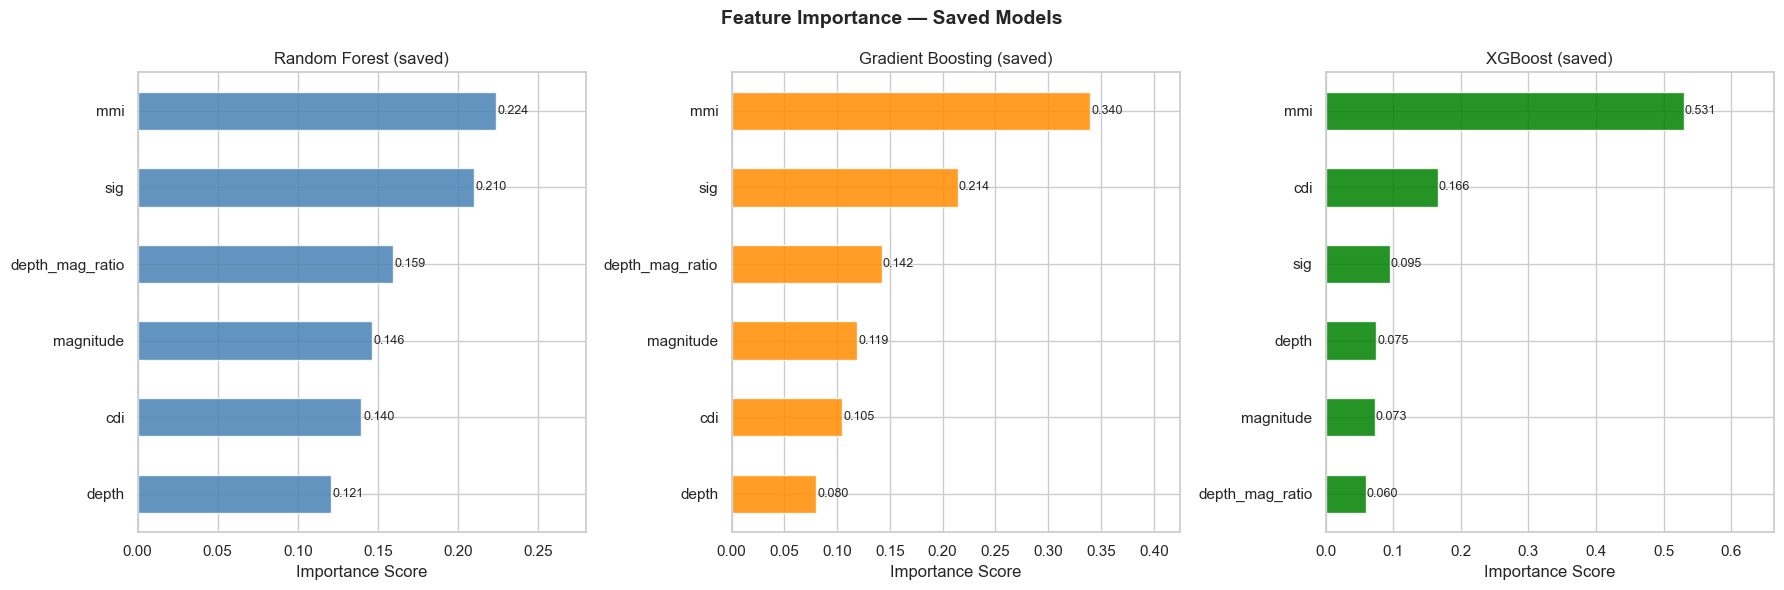


Feature Importance Summary:
                 Random Forest (saved)  Gradient Boosting (saved)  XGBoost (saved)
mmi                             0.2239                     0.3399           0.5305
sig                             0.2099                     0.2142           0.0953
depth_mag_ratio                 0.1593                     0.1422           0.0596
magnitude                       0.1465                     0.1190           0.0734
cdi                             0.1397                     0.1047           0.1659
depth                           0.1208                     0.0801           0.0752


In [15]:
importance_models = {
    'Random Forest (saved)': rf_model,
    'Gradient Boosting (saved)': gb_model,
    'XGBoost (saved)': xgb_model
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_fi = ['steelblue', 'darkorange', 'green']

for ax, (name, model), color in zip(axes, importance_models.items(), colors_fi):
    fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    fi.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, fi.max() * 1.25)
    for i, v in enumerate(fi):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance — Saved Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fi_df = pd.DataFrame(
    {name: model.feature_importances_ for name, model in importance_models.items()},
    index=FEATURES
).sort_values('Random Forest (saved)', ascending=False)
print('\nFeature Importance Summary:')
print(fi_df.round(4).to_string())

## 6. SHAP Values (Explainability)

SHAP values computed.
SHAP 3D shape: (252, 6, 4)


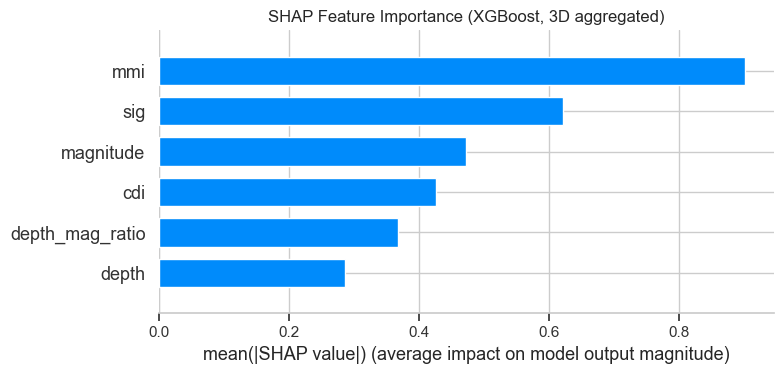

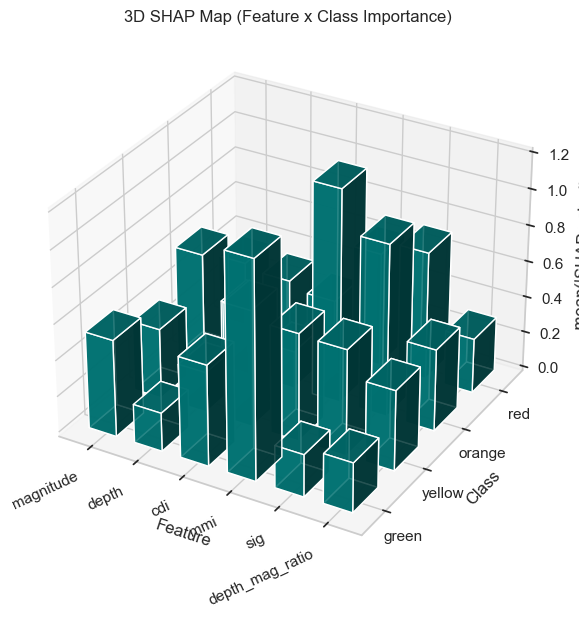

In [17]:
# Use TreeExplainer on XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Normalize SHAP output to a 3D array: (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    # list[class] -> (n_classes, n_samples, n_features) -> transpose
    shap_3d = np.stack(shap_values, axis=0).transpose(1, 2, 0)
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_3d = shap_values
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 2:
    # Binary/single-output fallback: expand to one class dimension
    shap_3d = shap_values[:, :, np.newaxis]
else:
    raise ValueError('Unexpected SHAP output format.')

print('SHAP values computed.')
print(f'SHAP 3D shape: {shap_3d.shape}')

# Aggregate class-wise importance for summary bar plot (2D)
shap_2d = np.mean(np.abs(shap_3d), axis=2)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_2d, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (XGBoost, 3D aggregated)')
plt.tight_layout()
plt.show()

# Build a true 3D map: feature importance per class
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

class_order = sorted(LABEL_MAP.keys())
class_names = [LABEL_MAP[c] for c in class_order]

# mean absolute SHAP for each (feature, class)
importance_fc = np.mean(np.abs(shap_3d), axis=0)  # shape: (n_features, n_classes)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

xpos, ypos = np.meshgrid(np.arange(len(FEATURES)), np.arange(len(class_names)), indexing='ij')
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos, dtype=float)

dx = np.full_like(xpos, 0.6, dtype=float)
dy = np.full_like(ypos, 0.6, dtype=float)
dz = importance_fc.ravel()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, alpha=0.85, color='teal')
ax.set_xticks(np.arange(len(FEATURES)) + 0.3)
ax.set_xticklabels(FEATURES, rotation=25, ha='right')
ax.set_yticks(np.arange(len(class_names)) + 0.3)
ax.set_yticklabels(class_names)
ax.set_xlabel('Feature')
ax.set_ylabel('Class')
ax.set_zlabel('mean(|SHAP value|)')
ax.set_title('3D SHAP Map (Feature x Class Importance)')

plt.tight_layout()
plt.show()